# Phase 3 — Statistics & Visualisation

**Input:** `data/fitness.db` (built in Phase 2)  
**Goal:** Descriptive stats, volume/frequency trends, and strength progression for key exercises.

---
### Notebook structure
1. Setup & Load Data
2. Descriptive Stats
3. Training Frequency Trend
4. Volume Trend
5. Strength Progression — Key Exercises
6. Correlation: Frequency vs. Strength
7. Personal Records Timeline
8. Weekday Training Heatmap

## 1. Setup & Load Data

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.float_format", "{:.1f}".format)
sns.set_theme(style="whitegrid", palette="muted")

DB_PATH = Path("../data/fitness.db")
conn = sqlite3.connect(DB_PATH)
print(f"Connected: {DB_PATH.resolve()}")

Connected: C:\projects\FitnessData\data\fitness.db


In [2]:
workouts = pd.read_sql("SELECT * FROM workouts", conn, parse_dates=["date"])
sets     = pd.read_sql("SELECT * FROM sets",     conn, parse_dates=["date"])

print(f"workouts : {len(workouts):,} rows")
print(f"sets     : {len(sets):,} rows")

workouts : 756 rows
sets     : 17,399 rows


In [3]:
KEY_EXERCISES = {
    "Hack Squat":           "Hack Squat",
    "Incline Bench Press":  "Incline Bench Press (Dumbbell)",
    "Chest Dip":            "Chest Dip",
    "Pull Up":              "Pull Up",
    "Romanian Deadlift":    "Romanian Deadlift (Barbell)",
    "Overhead Press":       "Seated Overhead Press (Dumbbell)",
}

## 2. Descriptive Stats

Basic summary statistics for workout duration, set count, and volume per session.

In [4]:
workouts[["duration_min", "total_sets", "total_volume_kg"]].describe().round(1)

,duration_min,total_sets,total_volume_kg
count,756.0,756.0,756.0
mean,75.1,23.0,11689.4
std,11.4,3.7,6444.0
min,47.2,15.0,0.0
25%,67.1,20.8,6841.1
50%,75.7,23.0,10664.0
75%,83.4,26.0,15964.2
max,99.9,35.0,35145.0


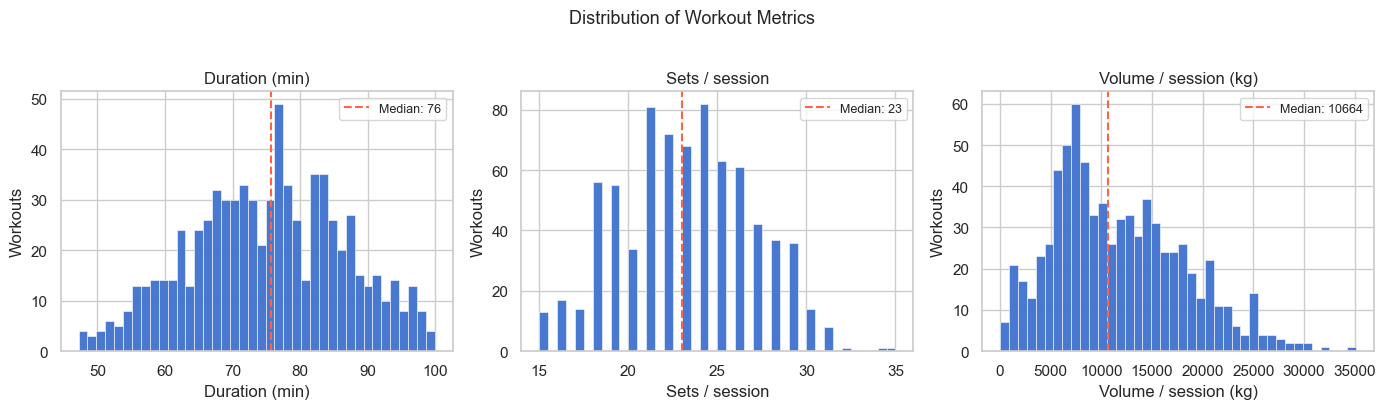

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cols   = ["duration_min",   "total_sets",      "total_volume_kg"]
labels = ["Duration (min)", "Sets / session",  "Volume / session (kg)"]

for ax, col, label in zip(axes, cols, labels):
    ax.hist(workouts[col].dropna(), bins=40, edgecolor="white", linewidth=0.4)
    ax.axvline(workouts[col].median(), color="tomato", lw=1.5, linestyle="--",
               label=f"Median: {workouts[col].median():.0f}")
    ax.set(title=label, xlabel=label, ylabel="Workouts")
    ax.legend(fontsize=9)

plt.suptitle("Distribution of Workout Metrics", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 3. Training Frequency Trend

Workouts per week over the full 6-year period, with a 12-week rolling average to smooth out holidays and gaps.

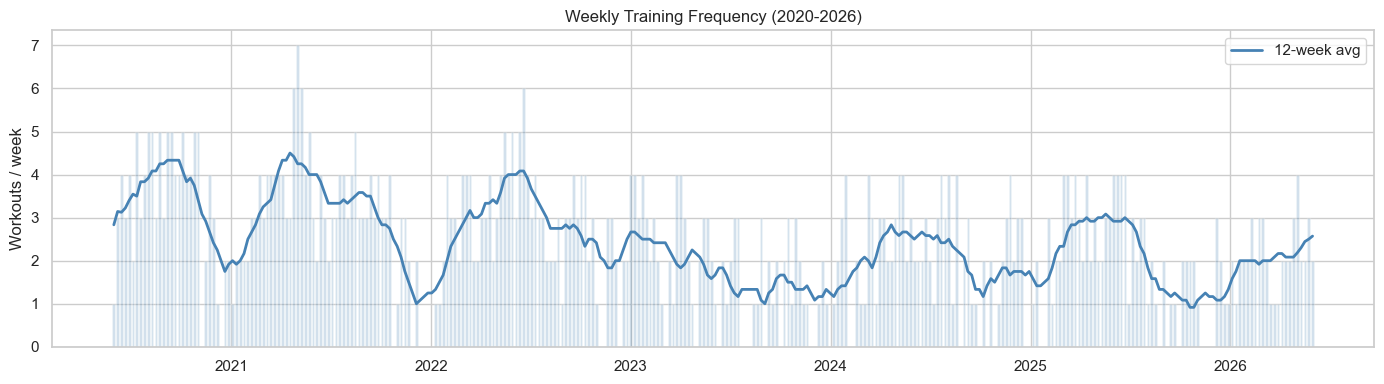

In [6]:
weekly = (
    workouts.set_index("date")
    .resample("W")["workout_id"]
    .count()
    .rename("workouts")
    .reset_index()
)
weekly["rolling_avg"] = weekly["workouts"].rolling(12, center=True, min_periods=6).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(weekly["date"], weekly["workouts"], width=5, alpha=0.25, color="steelblue")
ax.plot(weekly["date"], weekly["rolling_avg"], color="steelblue", lw=2, label="12-week avg")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set(title="Weekly Training Frequency (2020-2026)", ylabel="Workouts / week", xlabel="")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Volume Trend

Monthly total volume (kg lifted) with a 3-month rolling average.

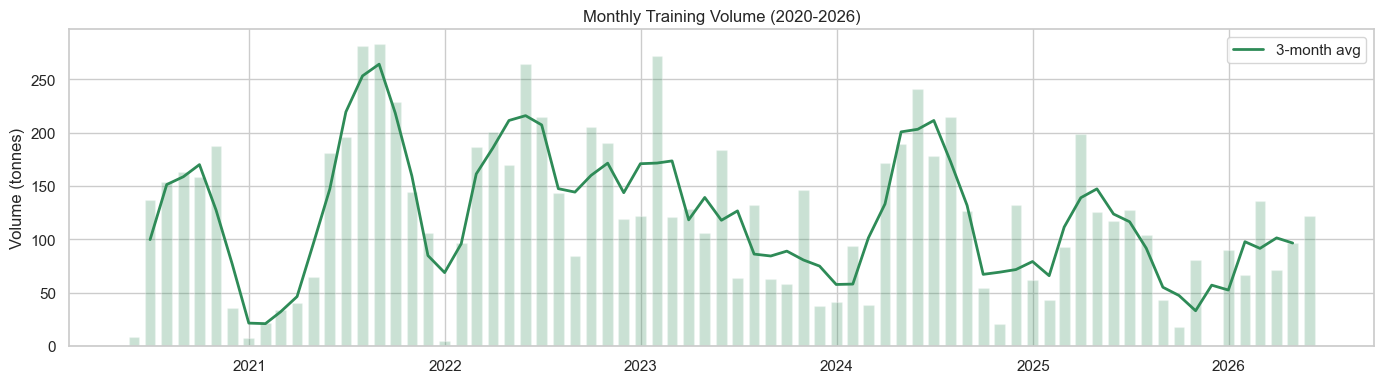

In [7]:
monthly_vol = (
    workouts.set_index("date")
    .resample("ME")["total_volume_kg"]
    .sum()
    .reset_index()
)
monthly_vol["rolling_avg"] = monthly_vol["total_volume_kg"].rolling(3, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly_vol["date"], monthly_vol["total_volume_kg"] / 1000,
       width=20, alpha=0.25, color="seagreen")
ax.plot(monthly_vol["date"], monthly_vol["rolling_avg"] / 1000,
        color="seagreen", lw=2, label="3-month avg")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set(title="Monthly Training Volume (2020-2026)", ylabel="Volume (tonnes)", xlabel="")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Strength Progression — Key Exercises

Monthly best estimated 1RM (Epley formula) per exercise, with a 3-month rolling average and a linear trend line.

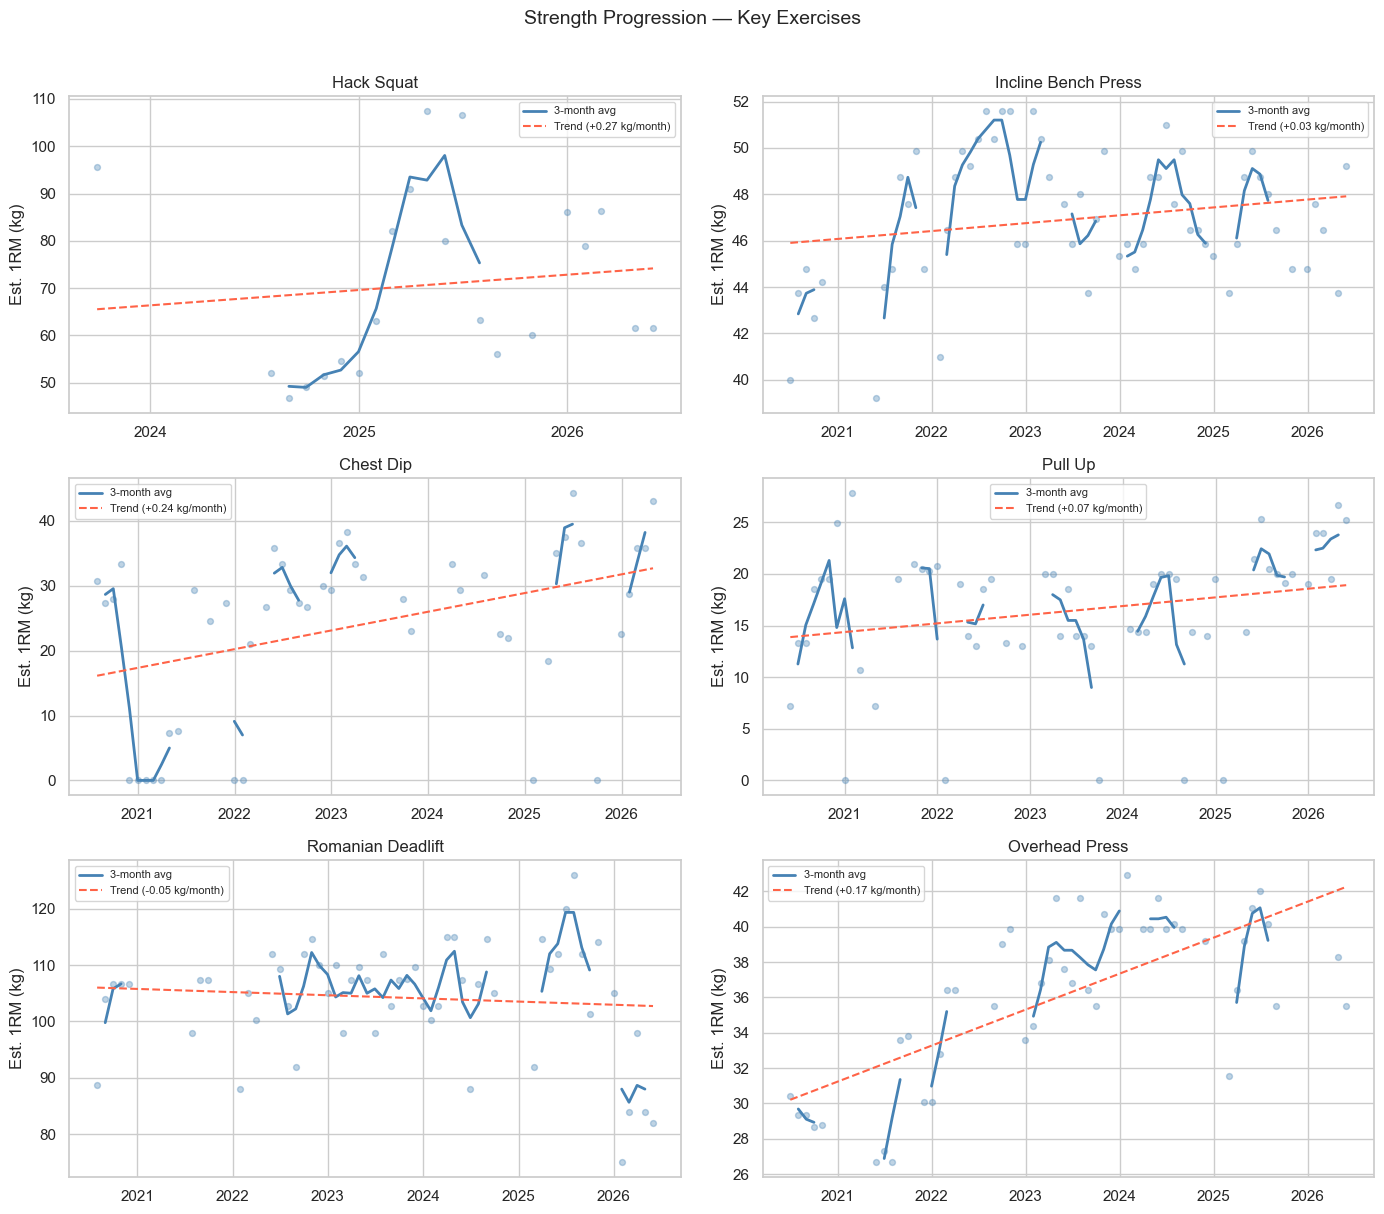

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (label, exercise) in enumerate(KEY_EXERCISES.items()):
    ex = sets[sets["exercise_name"] == exercise].copy()
    monthly = (
        ex.set_index("date")
        .resample("ME")["estimated_1rm"]
        .max()
        .reset_index()
    )
    monthly["rolling"] = monthly["estimated_1rm"].rolling(3, center=True).mean()

    # Linear trend line
    days = (monthly["date"] - monthly["date"].min()).dt.days.values
    valid = monthly["estimated_1rm"].notna()
    slope, intercept = np.polyfit(days[valid], monthly["estimated_1rm"][valid], 1)
    trend = slope * days + intercept

    ax = axes[idx]
    ax.scatter(monthly["date"], monthly["estimated_1rm"],
               alpha=0.35, s=18, color="steelblue", zorder=2)
    ax.plot(monthly["date"], monthly["rolling"],
            color="steelblue", lw=2, label="3-month avg")
    ax.plot(monthly["date"], trend,
            color="tomato", lw=1.5, linestyle="--",
            label=f"Trend ({slope * 30:+.2f} kg/month)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.set(title=label, ylabel="Est. 1RM (kg)", xlabel="")
    ax.legend(fontsize=8)

plt.suptitle("Strength Progression — Key Exercises", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Correlation: Training Frequency vs. Strength

Does training more often in a month correlate with a higher 1RM that month?  
We compute Pearson *r* for each key exercise (monthly workouts vs. monthly best 1RM).

In [9]:
monthly_freq = (
    workouts.set_index("date")
    .resample("ME")["workout_id"]
    .count()
    .rename("workouts_per_month")
)

results = []
for label, exercise in KEY_EXERCISES.items():
    monthly_1rm = (
        sets[sets["exercise_name"] == exercise]
        .set_index("date")
        .resample("ME")["estimated_1rm"]
        .max()
        .rename("best_1rm")
    )
    combined = pd.concat([monthly_freq, monthly_1rm], axis=1).dropna()
    r = combined["workouts_per_month"].corr(combined["best_1rm"])
    results.append({"exercise": label, "n_months": len(combined), "pearson_r": round(r, 2)})

corr_df = pd.DataFrame(results).sort_values("pearson_r", ascending=False)
corr_df

,exercise,n_months,pearson_r
0,Hack Squat,21,0.4
2,Chest Dip,48,0.2
3,Pull Up,57,0.2
4,Romanian Deadlift,55,0.1
1,Incline Bench Press,59,-0.0
5,Overhead Press,48,-0.4


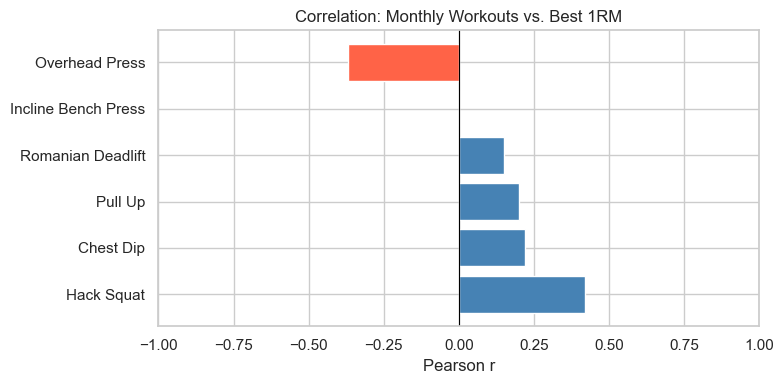

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tomato" if r < 0 else "steelblue" for r in corr_df["pearson_r"]]
ax.barh(corr_df["exercise"], corr_df["pearson_r"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Correlation: Monthly Workouts vs. Best 1RM",
       xlabel="Pearson r", xlim=(-1, 1))
plt.tight_layout()
plt.show()

## 7. Personal Records Timeline

When was the all-time best estimated 1RM set for each key exercise?

In [11]:
pr_rows = []
for label, exercise in KEY_EXERCISES.items():
    ex = sets[sets["exercise_name"] == exercise]
    best_idx = ex["estimated_1rm"].idxmax()
    row = ex.loc[best_idx]
    pr_rows.append({
        "exercise":         label,
        "pr_date":          row["date"],
        "estimated_1rm_kg": round(row["estimated_1rm"], 1),
        "weight_kg":        row["weight_kg"],
        "reps":             int(row["reps"]),
    })

pr_df = pd.DataFrame(pr_rows).sort_values("pr_date").reset_index(drop=True)
pr_df

,exercise,pr_date,estimated_1rm_kg,weight_kg,reps
0,Pull Up,2021-01-14 15:01:51,27.9,22.0,8
1,Incline Bench Press,2022-07-10 14:08:42,51.6,36.0,13
2,Overhead Press,2024-01-28 16:43:19,42.9,28.0,16
3,Hack Squat,2025-04-11 17:32:41,107.5,75.0,13
4,Chest Dip,2025-06-12 13:42:50,44.3,35.0,8
5,Romanian Deadlift,2025-07-16 14:34:21,126.0,90.0,12


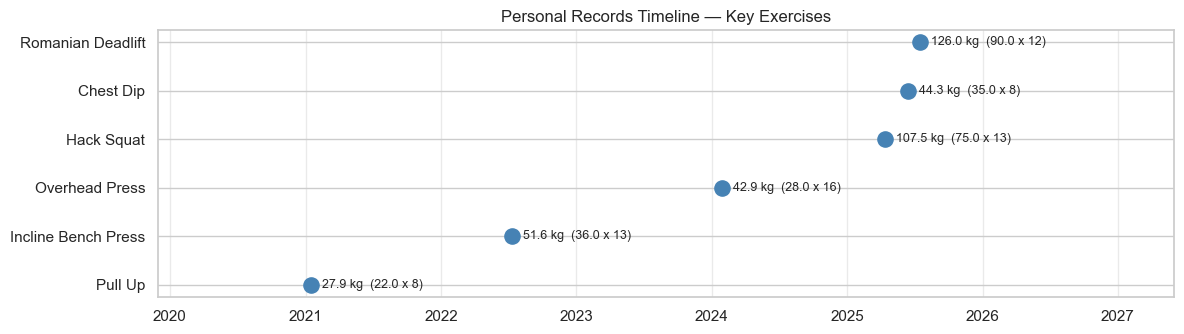

In [12]:
fig, ax = plt.subplots(figsize=(12, 3.5))

for i, (_, row) in enumerate(pr_df.iterrows()):
    ax.scatter(row["pr_date"], i, s=120, zorder=3, color="steelblue")
    ax.annotate(
        f"{row['estimated_1rm_kg']} kg  ({row['weight_kg']} x {row['reps']})",
        xy=(row["pr_date"], i),
        xytext=(8, 0), textcoords="offset points",
        fontsize=9, va="center",
    )

ax.set_yticks(range(len(pr_df)))
ax.set_yticklabels(pr_df["exercise"])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set(title="Personal Records Timeline — Key Exercises", xlabel="")
ax.set_xlim(pd.Timestamp("2019-12-01"), pd.Timestamp("2027-06-01"))
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Weekday Training Heatmap

How is training distributed across the week, year by year?

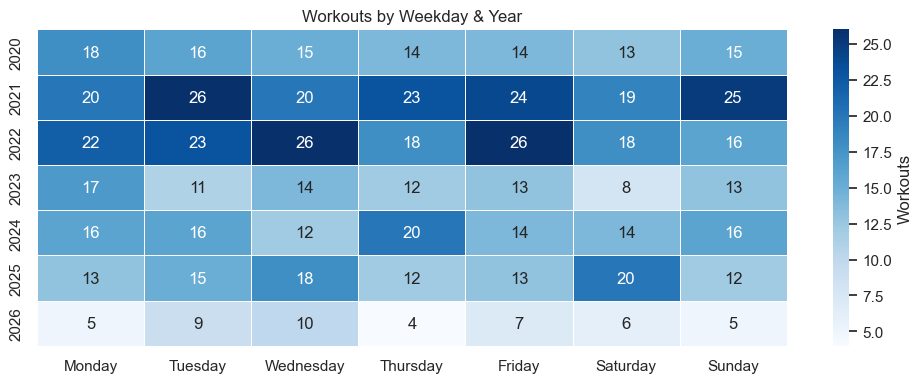

In [13]:
workouts["weekday"] = workouts["date"].dt.day_name()
workouts["year"]    = workouts["date"].dt.year

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

heatmap_data = (
    workouts.groupby(["year", "weekday"])["workout_id"]
    .count()
    .unstack(fill_value=0)
    .reindex(columns=weekday_order)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    heatmap_data, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, linecolor="white", ax=ax,
    cbar_kws={"label": "Workouts"},
)
ax.set(title="Workouts by Weekday & Year", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

In [14]:
conn.close()
print("Done.")

Done.
